<a href="https://colab.research.google.com/github/Mjdiazri/Code7Days/blob/main/Utilizando_chatgpt_como_asistente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <strong><font color="7b71ff">Análisis de datos con python: Utilizando ChatGPT como asistente</font></strong>


---

<img src="https://raw.githubusercontent.com/alura-cursos/ia-datascience-dataviz/main/imagens/logos/logo_branca_fundo_azul.png" alt="inserir alt">

# **Aula 1 - Conociendo los datos**

 Zoop es una gran minorista que atiende a todas las regiones de México a través de su e-commerce. Es conocida por la amplia variedad de productos que ofrece, buscando satisfacer a todo tipo de público. Posee una serie de centros de distribución (CDs) para la entrega de sus productos, la mayoría de ellos situados en el estado de Mexico. También posee una cadena de supermercados, y vamos a trabajar como científicos de datos para esta prestigiosa empresa.

### **Accesando a los datos**

In [6]:
url = 'https://gist.githubusercontent.com/ahcamachod/24a6235f7cdf255501b5ab4f9b0fd97f/raw/fa329f6d6c1b6b00b3ba457cdc850b53210633ca/zoop_market.json'

> #### <strong><font color="7b71ff" size =6>Prompt:</font></strong>

Vamos a actuar como científicos de datos en Zoop.

Recibimos datos en formato de archivo JSON, estructurados en listas y diccionarios. El archivo está disponible en una URL de Github.

Necesitamos analizar esos datos para ayudar en las decisiones de la empresa. Programamos en Python y conocemos las bibliotecas de análisis de datos Numpy y Pandas. Por lo tanto, prioriza el uso de estas bibliotecas.

Igualmente, infórmanos cómo podemos leer estos datos en formato JSON y para poder visualizarlos en formato de tabla en Python.

In [2]:
import pandas as pd
import numpy as np

In [7]:
#Leer archivo .json con metodo read_json de pandas
df = pd.read_json(url)

In [5]:
df

,index,item_identificador,tienda_identificador,ventas_totales,item,tienda
0,0,FDB08,OUT018,176503.58,"{'item_peso': 6.055, 'item_contenido_grasa': '...","{'tienda_ano_establecimiento': 2019, 'tienda_t..."
1,1,DRQ35,OUT049,185758.20,"{'item_peso': 9.3, 'item_contenido_grasa': 'Ba...","{'tienda_ano_establecimiento': 2009, 'tienda_t..."
2,2,FDD14,OUT018,165983.94,"{'item_peso': 20.7, 'item_contenido_grasa': 'B...","{'tienda_ano_establecimiento': 2019, 'tienda_t..."
3,3,FDY37,OUT045,314923.40,"{'item_peso': 17.0, 'item_contenido_grasa': 'R...","{'tienda_ano_establecimiento': 2012, 'tienda_t..."
4,4,FDY59,OUT018,64782.34,"{'item_peso': 8.195, 'item_contenido_grasa': '...","{'tienda_ano_establecimiento': 2019, 'tienda_t..."
...,...,...,...,...,...,...
8545,8545,FDY08,OUT010,28096.76,"{'item_peso': 9.395, 'item_contenido_grasa': '...","{'tienda_ano_establecimiento': 2008, 'tienda_t..."
8546,8546,FDC41,OUT017,130163.90,"{'item_peso': 15.6, 'item_contenido_grasa': 'B...","{'tienda_ano_establecimiento': 2017, 'tienda_t..."
8547,8547,NCQ53,OUT045,614533.40,"{'item_peso': 17.6, 'item_contenido_grasa': 'B...","{'tienda_ano_establecimiento': 2012, 'tienda_t..."
8548,8548,FDL46,OUT017,164985.24,"{'item_peso': 20.35, 'item_contenido_grasa': '...","{'tienda_ano_establecimiento': 2017, 'tienda_t..."


> #### <strong><font color="7b71ff" size =6>Prompt:</font></strong>


El DataFrame "df" posee las columnas "item_identificador", "tienda_identificador", "ventas_totales", "item" y "tienda".

Las columnas "item" y "tienda" contienen diccionarios anidados dentro de cada una de las filas. ¿Cómo puedo transformar los datos de los diccionarios y columnas para hacerlos más accesibles en mi DataFrame?


In [8]:
#Normalizando columna de item y tienda de ' a "" , ya que no corresponde a un diccionario real sino a un string con ast(su nombre significa Abstract Syntax Trees (árboles de sintaxis abstracta). Sirve principalmente para analizar y manipular código fuente de Python como si fuera una estructura de datos.)
import ast

# Convertir cada string que representa un diccionario a un diccionario real
df = pd.read_json(url)
df['item'] = df['item'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)


In [9]:
item_df = pd.json_normalize(df['item'])
item_df


,item_peso,item_contenido_grasa,item_visibilidad,item_tipo,item_precio,item_cantidad_venta
0,6.055,Bajo Contenido de Grasa,0.031230,Frutas y Vegetales,160.36,None
1,9.300,Bajo Contenido de Grasa,0.042357,Bebidas Alcohólicas,123.24,None
2,20.700,Bajo Contenido de Grasa,0.170500,Enlatados,184.13,None
3,17.000,Regular,0.026623,Enlatados,144.25,None
4,8.195,Bajo Contenido de Grasa,0.000000,Dulcería,93.15,None
...,...,...,...,...,...,...
8545,9.395,Regular,0.286345,Frutas y Vegetales,139.18,None
8546,15.600,Bajo Contenido de Grasa,0.117575,Alimentos Congelados,75.67,None
8547,17.600,Bajo Contenido de Grasa,0.018944,Abarrotes,237.36,None
8548,20.350,bajo contenido de grasa,0.054363,Snacks,117.95,None


In [10]:
#Convirtiendo tienda
df['tienda'] = df['tienda'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [11]:
#Normalizando columnas
tienda_df = pd.json_normalize(df['tienda'])
tienda_df

,tienda_ano_establecimiento,tienda_tamano,tienda_tipo_ubicacion,tienda_tipo
0,2019,Medio,Nivel 3,Supermercado Tipo 2
1,2009,Medio,Nivel 1,Supermercado Tipo 1
2,2019,Medio,Nivel 3,Supermercado Tipo 2
3,2012,None,Nivel 2,Supermercado Tipo 1
4,2019,Medio,Nivel 3,Supermercado Tipo 2
...,...,...,...,...
8545,2008,None,Nivel 3,Mercado
8546,2017,None,Nivel 2,Supermercado Tipo 1
8547,2012,None,Nivel 2,Supermercado Tipo 1
8548,2017,None,Nivel 2,Supermercado Tipo 1


In [12]:
#Concatenar dataframes (item, tienda) con el original

df = pd.concat([df.drop(['item', 'tienda'], axis=1), item_df, tienda_df], axis=1)


In [13]:
df.head()

,index,item_identificador,tienda_identificador,ventas_totales,item_peso,item_contenido_grasa,item_visibilidad,item_tipo,item_precio,item_cantidad_venta,tienda_ano_establecimiento,tienda_tamano,tienda_tipo_ubicacion,tienda_tipo
0,0,FDB08,OUT018,176503.58,6.055,Bajo Contenido de Grasa,0.031230,Frutas y Vegetales,160.36,None,2019,Medio,Nivel 3,Supermercado Tipo 2
1,1,DRQ35,OUT049,185758.20,9.300,Bajo Contenido de Grasa,0.042357,Bebidas Alcohólicas,123.24,None,2009,Medio,Nivel 1,Supermercado Tipo 1
2,2,FDD14,OUT018,165983.94,20.700,Bajo Contenido de Grasa,0.170500,Enlatados,184.13,None,2019,Medio,Nivel 3,Supermercado Tipo 2
3,3,FDY37,OUT045,314923.40,17.000,Regular,0.026623,Enlatados,144.25,None,2012,None,Nivel 2,Supermercado Tipo 1
4,4,FDY59,OUT018,64782.34,8.195,Bajo Contenido de Grasa,0.000000,Dulcería,93.15,None,2019,Medio,Nivel 3,Supermercado Tipo 2


# **Clase 2 - Exploración de los dados**

> #### <strong><font color="7b71ff" size =6>Prompt:</font></strong>

El DataFrame "df" contiene datos referentes a las ventas de diversos productos en varias tiendas del supermercado. Se proporcionan los IDs de productos y los IDs de tiendas que comercializaron esos productos, el total recaudado en ventas, así como descripciones sobre el producto vendido y la tienda que lo vendió.

Estamos iniciando la etapa de exploración de datos, en la cual deseamos conocer los valores informados e identificar si existen valores ausentes, duplicados y otras inconsistencias.

Construye un código para ejecutar la etapa de exploración de datos usando Python, comentando el paso a paso de manera clara y objetiva.

No es necesario utilizar "print()" para mostrar el resultado de las consultas.

In [ ]:
#Comprender estructura general y realizar una validacion inicial de los datos
df.head()

,index,item_identificador,tienda_identificador,ventas_totales,item_peso,item_contenido_grasa,item_visibilidad,item_tipo,item_precio,item_cantidad_venta,tienda_ano_establecimiento,tienda_tamano,tienda_tipo_ubicacion,tienda_tipo
0,0,FDB08,OUT018,176503.58,6.055,Bajo Contenido de Grasa,0.031230,Frutas y Vegetales,160.36,None,2019,Medio,Nivel 3,Supermercado Tipo 2
1,1,DRQ35,OUT049,185758.20,9.300,Bajo Contenido de Grasa,0.042357,Bebidas Alcohólicas,123.24,None,2009,Medio,Nivel 1,Supermercado Tipo 1
2,2,FDD14,OUT018,165983.94,20.700,Bajo Contenido de Grasa,0.170500,Enlatados,184.13,None,2019,Medio,Nivel 3,Supermercado Tipo 2
3,3,FDY37,OUT045,314923.40,17.000,Regular,0.026623,Enlatados,144.25,None,2012,None,Nivel 2,Supermercado Tipo 1
4,4,FDY59,OUT018,64782.34,8.195,Bajo Contenido de Grasa,0.000000,Dulcería,93.15,None,2019,Medio,Nivel 3,Supermercado Tipo 2


In [ ]:
#Calcular estadistica descriptiva: Validar datos desde la estadistica (media, mediana)

df.describe()

,index,ventas_totales,item_peso,item_visibilidad,item_precio,tienda_ano_establecimiento
count,8550.000000,8.550000e+03,7081.000000,8550.000000,8550.000000,8550.000000
mean,4274.500000,2.181949e+05,12.855023,0.066150,141.007453,2007.830409
std,2468.316734,1.708098e+05,4.643508,0.051578,62.333062,8.372541
min,0.000000,3.329000e+03,4.555000,0.000000,31.290000,1995.000000
25%,2137.250000,8.349132e+04,8.770000,0.027024,93.787500,1997.000000
50%,4274.500000,1.794331e+05,12.600000,0.053978,142.935000,2009.000000
75%,6411.750000,3.100963e+05,16.850000,0.094646,185.760000,2014.000000
max,8549.000000,1.308696e+06,21.350000,0.328391,266.890000,2019.000000


In [ ]:
#Verificar estructura general y tipo de datos en cada columna. Validar metadatos

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8550 entries, 0 to 8549
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   index                       8550 non-null   int64  
 1   item_identificador          8550 non-null   object 
 2   tienda_identificador        8550 non-null   object 
 3   ventas_totales              8550 non-null   float64
 4   item_peso                   7081 non-null   float64
 5   item_contenido_grasa        8550 non-null   object 
 6   item_visibilidad            8550 non-null   float64
 7   item_tipo                   8550 non-null   object 
 8   item_precio                 8550 non-null   float64
 9   item_cantidad_venta         0 non-null      object 
 10  tienda_ano_establecimiento  8550 non-null   int64  
 11  tienda_tamano               6133 non-null   object 
 12  tienda_tipo_ubicacion       8550 non-null   object 
 13  tienda_tipo                 8550 

In [ ]:
#Conocer uso real de memoria
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8550 entries, 0 to 8549
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   index                       8550 non-null   int64  
 1   item_identificador          8550 non-null   object 
 2   tienda_identificador        8550 non-null   object 
 3   ventas_totales              8550 non-null   float64
 4   item_peso                   7081 non-null   float64
 5   item_contenido_grasa        8550 non-null   object 
 6   item_visibilidad            8550 non-null   float64
 7   item_tipo                   8550 non-null   object 
 8   item_precio                 8550 non-null   float64
 9   item_cantidad_venta         0 non-null      object 
 10  tienda_ano_establecimiento  8550 non-null   int64  
 11  tienda_tamano               6133 non-null   object 
 12  tienda_tipo_ubicacion       8550 non-null   object 
 13  tienda_tipo                 8550 

In [ ]:
# Comprobar valores ausentes y duplicados

#Valores ausentes o nulos
df.isnull().sum()

,0
index,0
item_identificador,0
tienda_identificador,0
ventas_totales,0
item_peso,1469
item_contenido_grasa,0
item_visibilidad,0
item_tipo,0
item_precio,0
item_cantidad_venta,8550


In [ ]:
#Cantidad de filas duplicadas

df.duplicated().sum()

np.int64(0)

In [ ]:
#Validar cantidad de valores unicos en columnas relevantes

df.nunique()

,0
index,8550
item_identificador,1559
tienda_identificador,10
ventas_totales,3493
item_peso,415
item_contenido_grasa,5
item_visibilidad,7880
item_tipo,16
item_precio,4839
item_cantidad_venta,0


In [ ]:
df['tienda_tamano'].unique()

array(['Medio', None, 'Pequeño', 'Grande'], dtype=object)

> #### <strong><font color="7b71ff" size =6>Prompt:</font></strong>

El DataFrame "df" contiene datos relacionados con las ventas durante un trimestre de un supermercado. Deseo utilizarlo para verificar el desempeño de esas ventas.

Durante la exploración del "df", identificamos algunas inconsistencias, como:

* Filas duplicadas,
* Valores nulos y
* Datos categóricos que fueron escritos de manera no estandarizada, dando la idea de que existen más categorías de las que realmente existen.

¿Qué debo hacer para garantizar que esas inconsistencias que encontré no afecten mi análisis?

# **Clase 3 - Limpieza y tratamiento de los datos**

> #### <strong><font color="7b71ff" size =6>Prompt:</font></strong>


Durante la exploración del DataFrame "df", identificamos 27 filas duplicadas usando "df.duplicated().sum()".

El objetivo es analizar los datos en "df" para medir el desempeño de una empresa durante un trimestre de ventas.

¿Qué debemos hacer con los datos duplicados para garantizar que no haya impacto negativo en el análisis?

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
#En caso que aparecieran duplicados se pueden eliminar con

df = df.drop_duplicates()

In [16]:
df.duplicated().sum()

np.int64(0)

> #### <strong><font color="7b71ff" size =6>Prompt:</font></strong>


Identificamos tres columnas en "df" que presentan valores nulos:

* La columna "item_cantidad_venta" tiene 8550 filas con valores nulos.
* La columna "item_peso" tiene 1469 filas con valores nulos.
* La columna "tienda_tamano" tiene 2417 filas con valores nulos.

Hubo un gran número de ventas de artículos durante el trimestre, y no hay justificación para la ausencia de datos en la columna "item_cantidad_venta", lo que la convierte en una columna prescindible.

La columna "item_peso" contiene valores del tipo float, representando el peso en gramos de los productos.

La columna "tienda_tamano" tiene tres categorías de tamaño para supermercados.

¿Cómo debo manejar estos datos nulos para garantizar que mi análisis no se vea afectado?

In [17]:
# Ya que la columna item_cantidad_venta tiene todos los valores nulos, se elimina
df = df.drop(columns=['item_cantidad_venta'])

In [18]:
#Se define rellenar los valores nulos de item_peso con el promedio

#Opcion 1_mas eficiente: df['item_peso'].fillna(df['item_peso'].mean(), inplace=True)
#Opecion 2_menos eficiente_mejor para principiantes:
df['item_peso'] = df['item_peso'].fillna(df['item_peso'].mean())

In [19]:
#Se opta por rellenar los valores nulos de tienda_tamano con la palabra "desconocido"
df['tienda_tamano'] = df['tienda_tamano'].fillna('Desconocido')

In [20]:
#Comprobacion

df.isnull().sum()

,0
index,0
item_identificador,0
tienda_identificador,0
ventas_totales,0
item_peso,0
item_contenido_grasa,0
item_visibilidad,0
item_tipo,0
item_precio,0
tienda_ano_establecimiento,0


In [21]:
df.describe()

,index,ventas_totales,item_peso,item_visibilidad,item_precio,tienda_ano_establecimiento
count,8550.000000,8.550000e+03,8550.000000,8550.000000,8550.000000,8550.000000
mean,4274.500000,2.181949e+05,12.855023,0.066150,141.007453,2007.830409
std,2468.316734,1.708098e+05,4.225763,0.051578,62.333062,8.372541
min,0.000000,3.329000e+03,4.555000,0.000000,31.290000,1995.000000
25%,2137.250000,8.349132e+04,9.302500,0.027024,93.787500,1997.000000
50%,4274.500000,1.794331e+05,12.855023,0.053978,142.935000,2009.000000
75%,6411.750000,3.100963e+05,16.000000,0.094646,185.760000,2014.000000
max,8549.000000,1.308696e+06,21.350000,0.328391,266.890000,2019.000000


> #### <strong><font color="7b71ff" size =6>Prompt:</font></strong>

La columna "item_conteudo_grasa" del DataFrame "df" presenta 5 valores únicos dados por: 'Bajo Contenido de Grasa', 'Regular', 'BTG', 'reg' y 'bajo contenido de grasa'.

Los valores únicos de la columna "item_contenido_grasa" deberían ser solo 'Bajo Contenido de Grasa' y 'Regular', pero fueron insertados sin estandarización, lo que resultó en más categorías de las deseadas.

¿Cómo puedo ajustar los datos de la columna "item_contenido_grasa" para mantener solo las dos categorías estándar?

In [22]:
#Comprobar valores unicos de la columna item contenido grasa

#Opcion 1: Devuelve solo la lista de valores unicos
df['item_contenido_grasa'].unique()


array(['Bajo Contenido de Grasa', 'Regular', 'BCG', 'reg',
       'bajo contenido de grasa'], dtype=object)

In [23]:
#Opcion 2: Devuelve los valores unicos en orden de acuerdo a la frecuencia en el data frame(Cuantas veces aparece cada valor)
df['item_contenido_grasa'].value_counts().index

Index(['Bajo Contenido de Grasa', 'Regular', 'BCG', 'reg',
       'bajo contenido de grasa'],
      dtype='object', name='item_contenido_grasa')

In [24]:
#Ajuste

#Se opta por reemplazar los valores, estandarizando las categorias mediante un diccionario
diccionario_grasa = { 'bajo contenido de grasa' : 'Bajo Contenido de Grasa',
                      'BCG' : 'Bajo Contenido de Grasa',
                      'reg' : 'Regular',
                      'regular': 'Regular'
                    }

#Reemplazo
df['item_contenido_grasa'] = df['item_contenido_grasa'].replace(diccionario_grasa)



In [25]:
#Comprobar reemplazo realizado
df['item_contenido_grasa'].value_counts().index

Index(['Bajo Contenido de Grasa', 'Regular'], dtype='object', name='item_contenido_grasa')

In [26]:
#Validaciones finales con el dataframe
df.head()

,index,item_identificador,tienda_identificador,ventas_totales,item_peso,item_contenido_grasa,item_visibilidad,item_tipo,item_precio,tienda_ano_establecimiento,tienda_tamano,tienda_tipo_ubicacion,tienda_tipo
0,0,FDB08,OUT018,176503.58,6.055,Bajo Contenido de Grasa,0.031230,Frutas y Vegetales,160.36,2019,Medio,Nivel 3,Supermercado Tipo 2
1,1,DRQ35,OUT049,185758.20,9.300,Bajo Contenido de Grasa,0.042357,Bebidas Alcohólicas,123.24,2009,Medio,Nivel 1,Supermercado Tipo 1
2,2,FDD14,OUT018,165983.94,20.700,Bajo Contenido de Grasa,0.170500,Enlatados,184.13,2019,Medio,Nivel 3,Supermercado Tipo 2
3,3,FDY37,OUT045,314923.40,17.000,Regular,0.026623,Enlatados,144.25,2012,Desconocido,Nivel 2,Supermercado Tipo 1
4,4,FDY59,OUT018,64782.34,8.195,Bajo Contenido de Grasa,0.000000,Dulcería,93.15,2019,Medio,Nivel 3,Supermercado Tipo 2


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8550 entries, 0 to 8549
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   index                       8550 non-null   int64  
 1   item_identificador          8550 non-null   object 
 2   tienda_identificador        8550 non-null   object 
 3   ventas_totales              8550 non-null   float64
 4   item_peso                   8550 non-null   float64
 5   item_contenido_grasa        8550 non-null   object 
 6   item_visibilidad            8550 non-null   float64
 7   item_tipo                   8550 non-null   object 
 8   item_precio                 8550 non-null   float64
 9   tienda_ano_establecimiento  8550 non-null   int64  
 10  tienda_tamano               8550 non-null   object 
 11  tienda_tipo_ubicacion       8550 non-null   object 
 12  tienda_tipo                 8550 non-null   object 
dtypes: float64(4), int64(2), object(7

# **Clase 4 - Visualización de datos**

> #### <strong><font color="7b71ff" size =6>Prompt:</font></strong>

Los datos del DataFrame "df" están limpios y tratados. Ahora, deseo iniciar la etapa de construcción de gráficos para crear visualizaciones que ofrezcan un buen soporte al análisis del desempeño de ventas de la empresa.

Las columnas disponibles en "df" son las siguientes:
- "item_identificador": Número único asignado a cada ítem
- "tienda_identificador": Nombre único de la tienda
- "ventas_totales": Valor obtenido en ventas totales
- "item_peso": Peso del ítem en gramos
- "item_contenido_grasa": Contenido de grasa del ítem
- "item_visibilidad": Valor de posicionamiento de cada ítem
- "item_tipo": Tipo de utilidad del ítem
- "item_precio": Precio unitario del ítem
- "tienda_ano_establecimiento": Año de Establecimiento de la tienda
- "tienda_tamano": Tamaño de la tienda
- "tienda_tipo_ubicacion": Tipo de ubicación de la tienda
- "tienda_tipo": Tipo de tienda

El objetivo es encontrar patrones o información que se destaquen cuando nos referimos al total obtenido en ventas especificado en la columna "ventas_totales".

Con base en la información proporcionada, ¿qué tipos de visualizaciones serían útiles para alcanzar el objetivo de analizar el desempeño de ventas?

> #### <strong><font color="7b71ff" size =6>Prompt:</font></strong>

El DataFrame "df" contiene la columna "ventas_totales", que informa el valor en reales obtenido en ventas de productos por varias tiendas.

Además, en "df", tenemos la columna "tienda_tamano" con 4 categorías de tamaño para tiendas: 'Grande', 'Medio', 'Pequeño' y 'No registrado'.

Deseo crear una visualización que permita identificar el total obtenido en ventas para las cuatro categorías de tamaño de tienda y representarlas en un gráfico de barras.

Los datos en la columna "ventas_totales" necesitan ser agrupados por las categorías de "tienda_tamano".

La figura del gráfico debe seguir la identidad visual de la tienda, con el fondo de la figura y del gráfico en color "#ebebeb" y las barras en color "#e23155".

Además, es necesario mostrar el total de las ventas en millones encima de cada columna, con el texto de esta información en color "#19325c" y la estructura "MXN $ valor M".

Utiliza las bibliotecas de visualización de datos de Python para crear esta visualización.

In [28]:
#Librerias
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
#Para grafico ventas totales vs tienda tamano, se realiza la agrupacion

ventas_tamano = df.groupby('tienda_tamano')['ventas_totales'].sum()

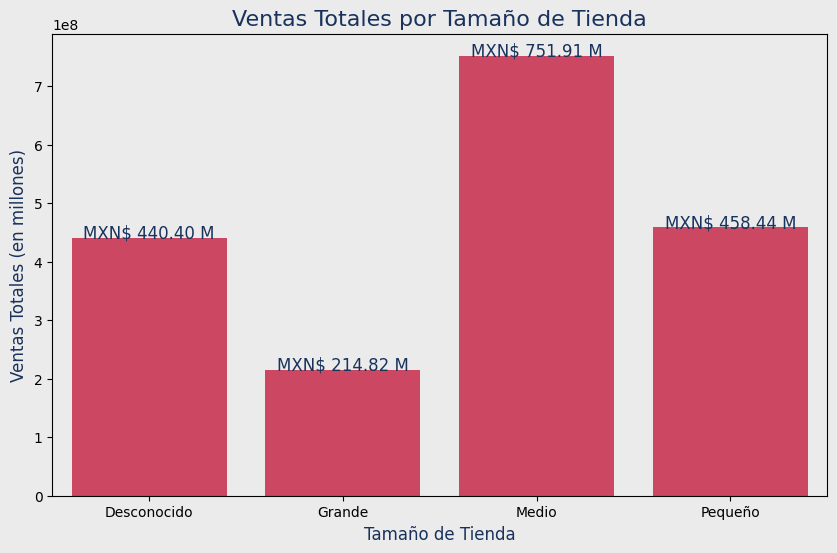

In [30]:
#Grafico

plt.figure(figsize=(10, 6))
sns.barplot(x=ventas_tamano.index, y=ventas_tamano.values, color='#e23155')

#Personalizacion
plt.gcf().set_facecolor('#ebebeb') #color fondo figura
plt.gca().set_facecolor('#ebebeb') #color fondo grafico

#Etiquetas
plt.title('Ventas Totales por Tamaño de Tienda', fontsize = 16, color = '#19325c')
plt.xlabel('Tamaño de Tienda', fontsize = 12,color = '#19325c')
plt.ylabel('Ventas Totales (en millones)', fontsize = 12,color = '#19325c')

#Mostrar valores sobre las barras
for i, valor in enumerate(ventas_tamano.values):
    plt.text(i, valor + 0.1, f'MXN$ {valor/1e6:.2f} M',  ha='center', fontsize = 12, color = '#19325c')

plt.xticks(rotation=0)
plt.show()


> #### <strong><font color="7b71ff" size =6>Prompt:</font></strong>


El DataFrame "df" contiene la columna "ventas_totales", que informa el valor en reales obtenido en ventas de productos por varias tiendas.

Además, en "df", tenemos la columna "tienda_tipo" con 4 categorías de tipo para tiendas: 'Supermercado Tipo 1', 'Supermercado Tipo 2', 'Mercado', 'Supermercado Tipo 3'.

Deseo crear una visualización que permita identificar el total obtenido en ventas para las cuatro categorías de tipo de tienda y representarlas en un gráfico de barras.

Los datos en la columna "ventas_totales" deben ser agrupados por las categorías de "tienda_tipo".

La figura de la gráfica debe seguir la identidad visual de la tienda, con el fondo de la figura y de la gráfica en color "#ebebeb" y las barras en color "#e23155".

Además, es necesario mostrar el total de las ventas en millones sobre cada columna, con el texto de esa información en color "#19325c" y la estructura "MXN$ valor M".

Utiliza las bibliotecas de visualización de datos de Python para crear esta visualización.

In [31]:
#Para grafico ventas totales vs tipo tienda, se realiza la agrupacion

ventas_tienda = df.groupby('tienda_tipo')['ventas_totales'].sum()

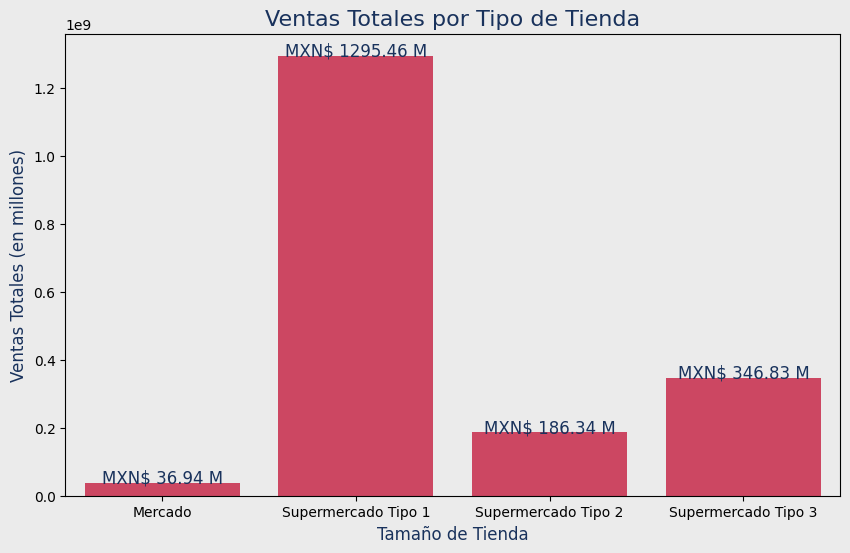

In [32]:
#Grafico

plt.figure(figsize=(10, 6))
sns.barplot(x=ventas_tienda.index, y=ventas_tienda.values, color='#e23155')

#Personalizacion
plt.gcf().set_facecolor('#ebebeb') #color fondo figura
plt.gca().set_facecolor('#ebebeb') #color fondo grafico

#Etiquetas
plt.title('Ventas Totales por Tipo de Tienda', fontsize = 16, color = '#19325c')
plt.xlabel('Tamaño de Tienda', fontsize = 12,color = '#19325c')
plt.ylabel('Ventas Totales (en millones)', fontsize = 12,color = '#19325c')

#Mostrar valores sobre las barras
for i, valor in enumerate(ventas_tienda.values):
    plt.text(i, valor + 0.1, f'MXN$ {valor/1e6:.2f} M',  ha='center', fontsize = 12, color = '#19325c')

plt.xticks(rotation=0)
plt.show()


> #### <strong><font color="7b71ff" size =6>Prompt:</font></strong>

El DataFrame "df" contiene la columna "ventas_totales", que informa el valor en reales obtenido en ventas de productos por varias tiendas.

Además, en "df", tenemos la columna "item_tipo" con 16 categorías de productos.

Deseo crear una visualización que permita identificar el total obtenido en ventas por categorías de productos en un gráfico de barras horizontales.

Los datos en la columna "ventas_totales" deben agruparse por las categorías de "item_tipo".

La figura de la representación debe seguir la identidad visual de la tienda, con el fondo de la figura y del gráfico en el color "#ebebeb".

Las barras deben estar en el color "#e23155".

Los valores de las barras deben estar ordenados para mantener un aspecto de embudo.

Además, es necesario mostrar el total de las ventas en millones dentro o al lado de cada barra, con el texto de esa información en el color "#19325c" y en la estructura "MXN$ valor M".

No muestres la cuadrícula en el gráfico.

Utiliza las bibliotecas de visualización de datos de Python para crear esta visualización.

In [33]:
#Para grafico ventas totales vs tipo de item (Ventas por tipo de producto), se realiza la agrupacion

ventas_item = df.groupby('item_tipo')['ventas_totales'].sum()

#Ordenar valores de menor a mayor para forma de embudo
ventas_item = ventas_item.sort_values(ascending=False)


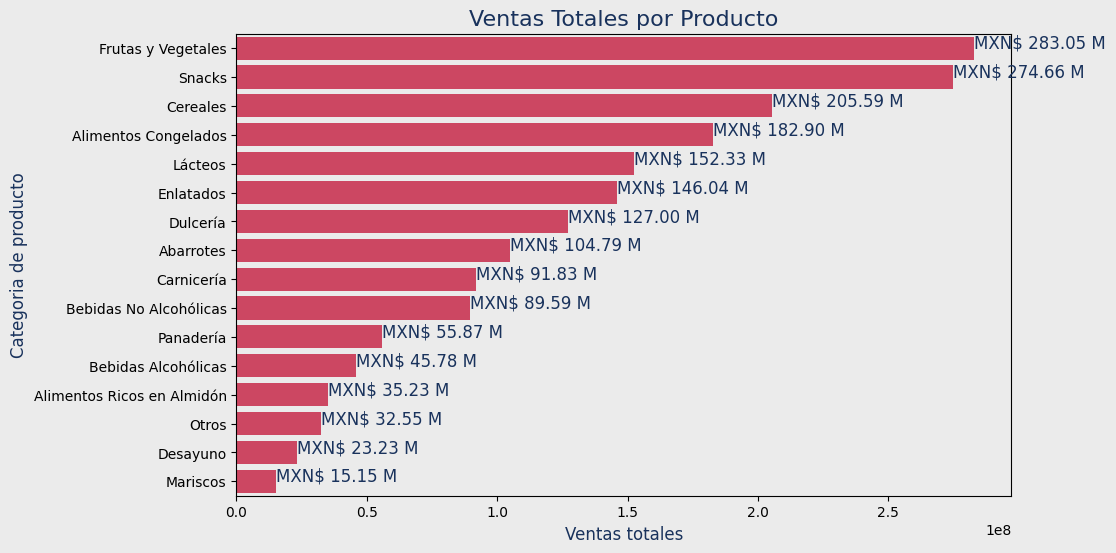

In [37]:
#Grafico

plt.figure(figsize=(10, 6))
sns.barplot(x=ventas_item.values, y=ventas_item.index, color='#e23155')

#Personalizacion
plt.gcf().set_facecolor('#ebebeb') #color fondo figura
plt.gca().set_facecolor('#ebebeb') #color fondo grafico

#Etiquetas
plt.title('Ventas Totales por Producto', fontsize = 16, color = '#19325c')
plt.xlabel('Ventas totales', fontsize = 12,color = '#19325c')
plt.ylabel('Categoria de producto', fontsize = 12,color = '#19325c')

#Mostrar valores sobre las barras
for i, valor in enumerate(ventas_item.values):
    plt.text(valor + 0.1, i,  f'MXN$ {valor/1e6:.2f} M',  ha='left', fontsize = 12, color = '#19325c')

# Do not show grid
plt.grid(False)

plt.show()

In [38]:
#Para grafico ventas totales vs cantidad de grasa, se realiza la agrupacion

ventas_grasa = df.groupby('item_contenido_grasa')['ventas_totales'].sum()



<ipython-input-42-96a1c3b8e5e1>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_grasa.index, y=ventas_grasa.values, palette=colores)


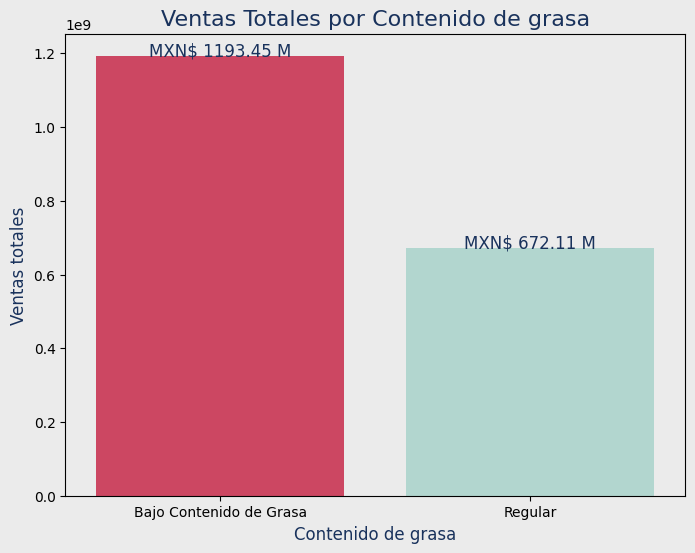

In [42]:
#Grafico

plt.figure(figsize=(8, 6))

#Colores especificos por barra
colores = {'Bajo Contenido de Grasa' : '#e23155', 'Regular': '#acdcd3'}

#Hacer grafico barras
sns.barplot(x=ventas_grasa.index, y=ventas_grasa.values, palette=colores)

#Personalizacion
plt.gcf().set_facecolor('#ebebeb') #color fondo figura
plt.gca().set_facecolor('#ebebeb') #color fondo grafico

#Etiquetas
plt.title('Ventas Totales por Contenido de grasa', fontsize = 16, color = '#19325c')
plt.xlabel('Contenido de grasa', fontsize = 12,color = '#19325c')
plt.ylabel('Ventas totales', fontsize = 12,color = '#19325c')

#Mostrar valores sobre las barras
for i, valor in enumerate(ventas_grasa.values):
    plt.text(i, valor + 0.1,  f'MXN$ {valor/1e6:.2f} M',  ha='center', fontsize = 12, color = '#19325c')

plt.show()